# Explore the ADL dataset

This notebook explores the ADL dataset (Arkiv for Dansk Litteratur) through various text analysis techniques. It performs basic data exploration, text cleaning, stopword removal, and collocation analysis to identify words that frequently appear near specific keywords. The analysis helps reveal semantic patterns and linguistic relationships in Danish literary texts.

In [102]:
## Import modules
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

## Read the CSV file

Load the dataset from a CSV file into a pandas DataFrame


In [113]:
df = pd.read_csv('adl_dataset.csv', encoding='utf-8')

## Explore the data

In [104]:
df.value_counts('year').to_frame().reset_index().head(10)

,year,count
0,1904,17
1,1920,8
2,1902,6
3,1901,6
4,1889,6
5,1921,5
6,1851,4
7,1912,4
8,1928,4
9,1926,4


In [105]:
df.value_counts('author').to_frame().reset_index().head(10)

,author,count
0,"Larsen, Karl.",18
1,"Hjortø, Knud.",16
2,"Brandes, Edvard.",13
3,"Rode, Helge.",12
4,"Michaëlis, Sophus.",11
5,"Grundtvig, N. F. S.",10
6,"Skjoldborg, Johan.",8
7,"Schandorph, Sophus.",8
8,"Bang, Herman.",7
9,"Hertz, Henrik.",5


In [106]:
def word_count(text):
    return len(re.findall(r'\b\S+\b', text))

df['word_count'] = df['text'].apply( lambda x : word_count(x)) 

df.groupby('author')['word_count'].sum()\
                                .to_frame()\
                                .sort_values('word_count', ascending=False)\
                                .reset_index()\
                                .head(10)

,author,word_count
0,"Grundtvig, N. F. S.",2148585
1,"Schandorph, Sophus.",1209914
2,"Hjortø, Knud.",886864
3,"Bang, Herman.",843214
4,"Larsen, Karl.",642502
5,"Brandes, Georg.",627489
6,"Heiberg, Johanne Luise.",395598
7,"Michaëlis, Sophus.",389488
8,"Brandes, Edvard.",362533
9,"Kidde, Harald.",359522


## Clean the text

To get more uniform text data I use regex methods. I use .findall() to find all data between word bounderies that is not a whitespace. I use .sub() to avoid numbers, words containing numbers, words with a lenght of 1 or 2; and any sequences of more than one whitespaces. Finaly I lower the letters and returns the clean text. 

In [107]:
# Make a function to clean the text using regular expressions
def clean(text): 
    
    text = ' '.join(re.findall(r'\b\S+\b', text))

    # Remove numbers and words containing numbers
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    
    # Remove short words (length 1 or 2)
    text = re.sub(r'\b\w{1,2}\b', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text) 

    # Convert text to lowercase
    text = text.lower()

    # return the text
    return text
    
# Apply the cleaning function to the text column
df['clean_text'] = df['text'].apply(lambda x: clean(x))

## Remove stopwords

I want to apply a collocation tool downstream, and in that I do not wish to include stopword, so I choose to make new text strings without stopwords, to be able to get better results out of a my collocation analysis.

I the folder "stopwords" I have a txt file with stopwords. I read the txt into the script, make it into a list, and with the make place for adding additional stuff to the list. 

In [108]:
# Load a list of danish stopwords from a text file
sw_file = 'adl_dataset_stopwords.txt'

with open(sw_file, 'r', encoding='utf-8') as f:
    stop_words = f.read().split()
    # Add additional stopwords
    stop_words.extend(['_', '/', "'"])

# Define a function to remove stopwords from the text
def remove_stopwords(clean_text):   
    # Change text to wordlist
    tokens = clean_text.split()
    tokens_wo_stopwords = [i for i in tokens if i.lower() not in stop_words]
    clean_text_wo_stopwords = ' '.join(tokens_wo_stopwords)
    return clean_text_wo_stopwords

# Apply the stopword removal function
df['clean_text_wo_stopwords'] = df['clean_text'].apply( lambda x : remove_stopwords(x))

## Collocation

This section performs collocation analysis to identify words that frequently appear near specific keywords in the corpus. Collocations are words that tend to co-occur with your target keywords, which can reveal semantic patterns, themes, and linguistic relationships in the text.

In [109]:
# Define keywords for collocation analysis
keywords = ['fader', 'moder', 'barn']

in_data_list = ' '.join(df['clean_text_wo_stopwords']).split()

# Initialize a dictionary to count keyword proximities
keyword_proximity_counts = {keyword: Counter() for keyword in keywords}
window_size = 10

# Count the proximity of words around each keyword
for i, token in enumerate(in_data_list):
    if token in keywords:
        # Define the window around the keyword
        start = max(0, i - window_size)
        end = min(len(in_data_list), i + window_size + 1)
        # Count terms in the window, excluding the keyword itself
        for j in range(start, end):
            if j != i:
                keyword_proximity_counts[token][in_data_list[j]] += 1

# Filter out terms with low counts
filtered_keyword_proximity_counts = {
    keyword: Counter({term: count for term, count in counts.items() if count >= 80})
    for keyword, counts in keyword_proximity_counts.items()}

## Visualise the collocations
If I print the content of the variable "filtered_keyword_proximity_counts" we can watch the different keywords together with the collocations. It is the collocations that exists after we have removed stopwords and defined a window size of 10. It can be a bit confusing to watch the data in the printed format, so I chose to use math plot lib to visualise the colllocations with bar plots.  

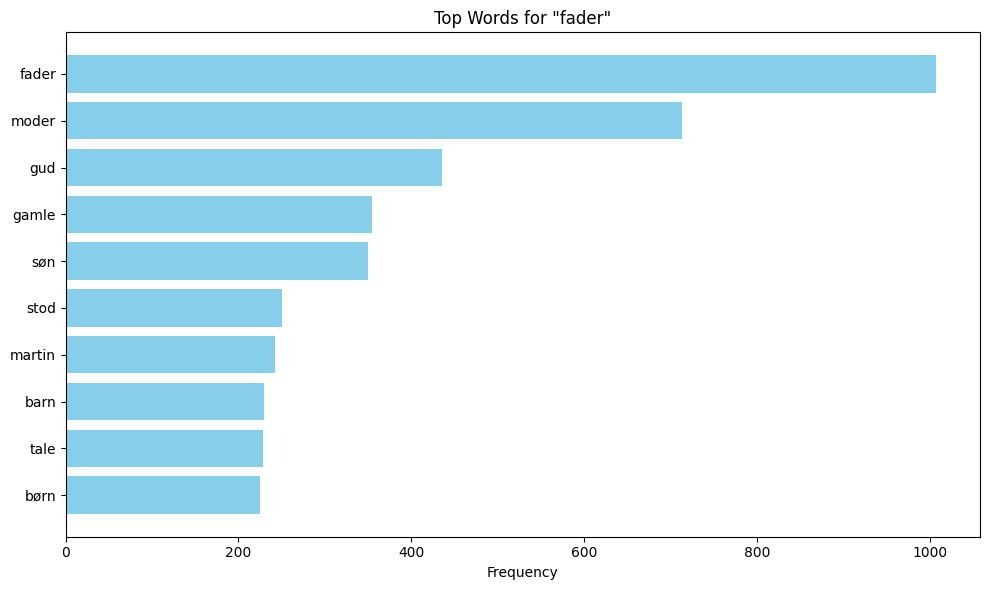

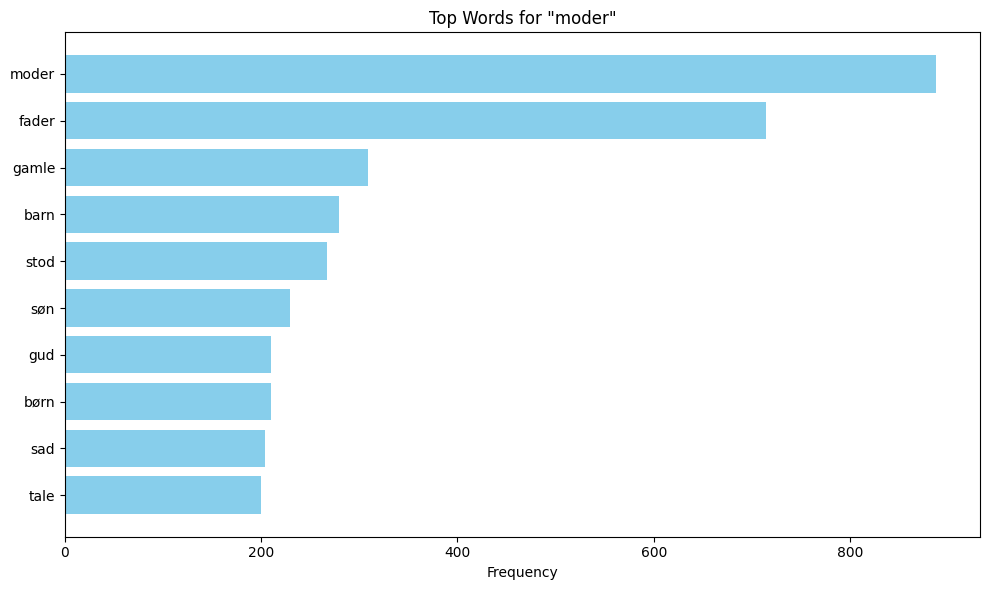

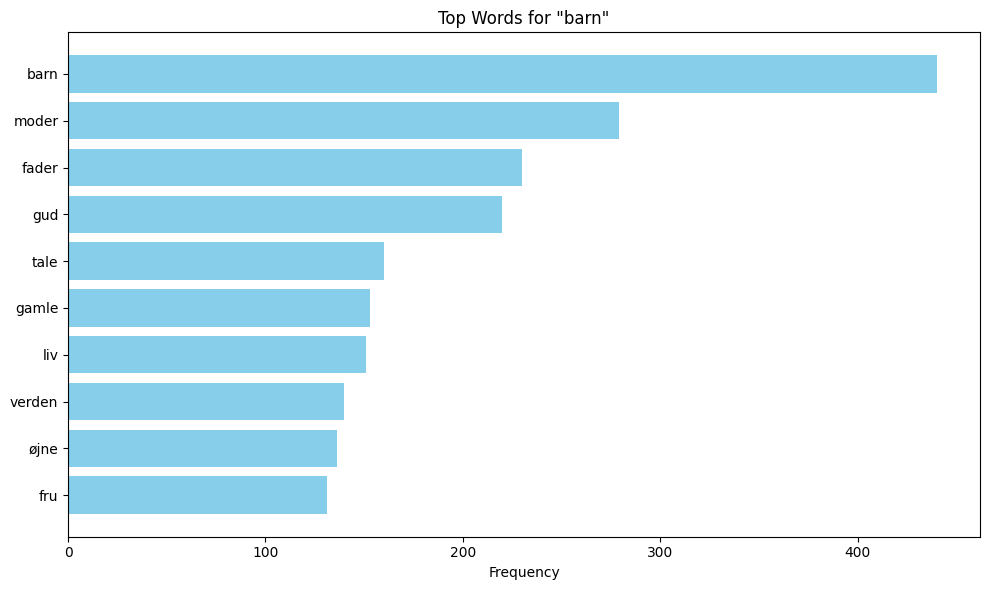

In [111]:
# Convert each group's Counter to a DataFrame
dfs = []
for keyword, counter in filtered_keyword_proximity_counts.items():
    df = pd.DataFrame(counter.items(), columns=['Word', 'Frequency'])
    df['Keyword_Group'] = keyword
    dfs.append(df)

# Concatenate all dataframes
all_data = pd.concat(dfs, ignore_index=True)

# Create individual bar charts for each keyword group
for keyword in filtered_keyword_proximity_counts.keys():
    df_subset = all_data[all_data['Keyword_Group'] == keyword]
    plt.figure(figsize=(10,6))
    df_subset = df_subset.sort_values(by='Frequency', ascending=False).head(10)
    plt.barh(df_subset['Word'], df_subset['Frequency'], color='skyblue')
    plt.xlabel('Frequency')
    plt.title(f'Top Words for "{keyword}"')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
